# Task 3 - Discrete Motion Model & Trajectory Tracking

## Implement a Python program that accepts motion commands in the format forward <val>, left <val>, and right <val>.

* Maintain and update the robot's pose as (x, y, theta).
* For every command executed, log the output to the terminal as:
  Initial Pos: (...) | Executing: <command> | Final Pos: (...)
* Once all commands are executed, plot the complete trajectory using Matplotlib, showing the path, start/end markers, and heading orientation arrows (quivers) at each waypoint.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = 0.0
y = 0.0
angle = 0.0

x_history = [x]
y_history = [y]
u_history = [np.cos(np.radians(angle))]
v_history = [np.sin(np.radians(angle))]

Enter commands
Press Enter on an empty line to finish and display the plot.

Initial Pos: (0.00, 0.00, 0.0°) | Executing: forward 60 | Final Pos: (60.00, 0.00, 0.0°)
Initial Pos: (60.00, 0.00, 0.0°) | Executing: right 90 | Final Pos: (60.00, 0.00, -90.0°)
Initial Pos: (60.00, 0.00, -90.0°) | Executing: forward 40 | Final Pos: (60.00, -40.00, -90.0°)
Initial Pos: (60.00, -40.00, -90.0°) | Executing: right 45 | Final Pos: (60.00, -40.00, -135.0°)
Initial Pos: (60.00, -40.00, -135.0°) | Executing: forward 25 | Final Pos: (42.32, -57.68, -135.0°)
Initial Pos: (42.32, -57.68, -135.0°) | Executing: left 45 | Final Pos: (42.32, -57.68, -90.0°)
Initial Pos: (42.32, -57.68, -90.0°) | Executing: forward 30 | Final Pos: (42.32, -87.68, -90.0°)
Initial Pos: (42.32, -87.68, -90.0°) | Executing: right 90 | Final Pos: (42.32, -87.68, -180.0°)
Initial Pos: (42.32, -87.68, -180.0°) | Executing: forward 55 | Final Pos: (-12.68, -87.68, -180.0°)


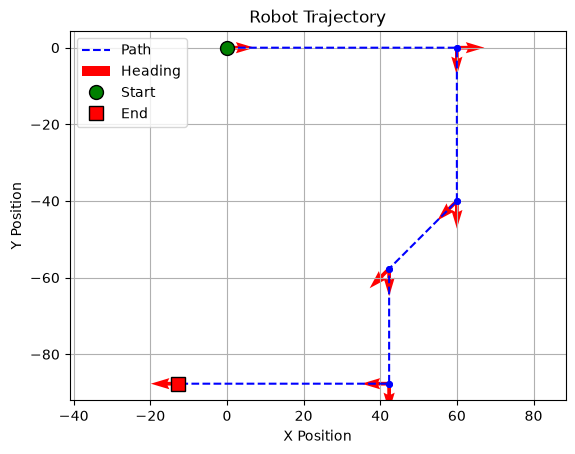

In [ ]:
print("Enter commands")
print("Press Enter on an empty line to finish and display the plot.\n")

while True:
    user_input = input().strip()
    if not user_input:
        break

    parts = user_input.split()
    if len(parts) != 2:
        print("Invalid command")
        continue

    action = parts[0].lower()
    try:
        val = float(parts[1])
    except ValueError:
        print("Invalid command")
        continue

    initial_pos = f"({x:.2f}, {y:.2f}, {angle:.1f}°)"

    if action == "forward":
        rad = np.radians(angle)
        x = x + val * np.cos(rad)
        y = y + val * np.sin(rad)
    elif action == "left":
        angle = angle + val
    elif action == "right":
        angle = angle - val
    else:
        print("Incorrect command")
        continue

    final_pos = f"({x:.2f}, {y:.2f}, {angle:.1f}°)"
    print(
        f"Initial Pos: {initial_pos} | Executing: {user_input} | Final Pos: {final_pos}"
    )

    rad = np.radians(angle)
    x_history.append(x)
    y_history.append(y)
    u_history.append(np.cos(rad))
    v_history.append(np.sin(rad))

    """
    rad = np.radians(angle)
    if action in ["left", "right"]:
        u_history[-1] = np.cos(rad)
        v_history[-1] = np.sin(rad)
    else:
        x_history.append(x)
        y_history.append(y)
        u_history.append(np.cos(rad))
        v_history.append(np.sin(rad))
    """

plt.figure()
plt.plot(x_history,y_history,"b--",label="Path")
plt.plot(x_history,y_history,"bo",markersize=4)
plt.quiver(x_history,y_history,u_history,v_history,color="red",label="Heading",angles="xy",)
plt.plot(x_history[0],y_history[0],"go",markersize=10,markeredgecolor="black",label="Start",)
plt.plot(x_history[-1],y_history[-1],"rs",markersize=10,markeredgecolor="black",label="End",)
plt.gca().set_aspect("equal", adjustable="datalim")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Robot Trajectory")
plt.grid(True)
plt.legend()
plt.show()


